In [180]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit



In [182]:
data = pd.read_csv("data/Raw Data.csv")
data.head()


,Time (s),Acceleration x (m/s^2),Acceleration y (m/s^2),Acceleration z (m/s^2),Absolute acceleration (m/s^2)
0,0.018343,8.477771,0.471386,5.223532,9.968956
1,0.020721,8.458628,0.461815,5.230711,9.956003
2,0.023099,8.415557,0.459422,5.197211,9.901700
3,0.025478,8.389236,0.457029,5.170890,9.865408
4,0.027856,8.370093,0.471386,5.144569,9.836018


## To visualize the absolute acceleration we plot it

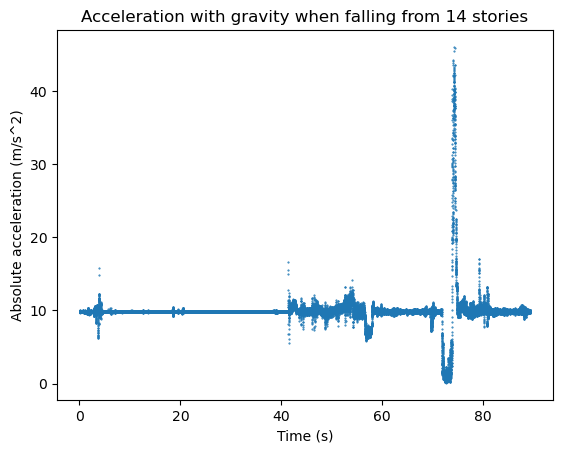

In [184]:
plt.errorbar(data.iloc[:, 0], data.iloc[:, -1], fmt=".", markersize=1)
plt.xlabel(data.columns[0]); plt.ylabel(data.columns[-1])
plt.title("Acceleration with gravity when falling from 14 stories")
pass

### From our my previous lab we got the estimate of gravity in batimore when our phone is at rest to be

$$ \text{Estimated gravity} = 9.80 \pm 0.12 \, \text{m/s}^2 $$

#### Subtracting this value from all our data points and deleting the columns we don't need anymore

In [189]:
gravity = 9.80
data = data[["Time (s)", "Absolute acceleration (m/s^2)"]]
data["Absolute acceleration (m/s^2)"] -= gravity

In [190]:
data.head()

,Time (s),Absolute acceleration (m/s^2)
0,0.018343,0.168956
1,0.020721,0.156003
2,0.023099,0.101700
3,0.025478,0.065408
4,0.027856,0.036018


### Plotting the graph after the we subtracted the gravity

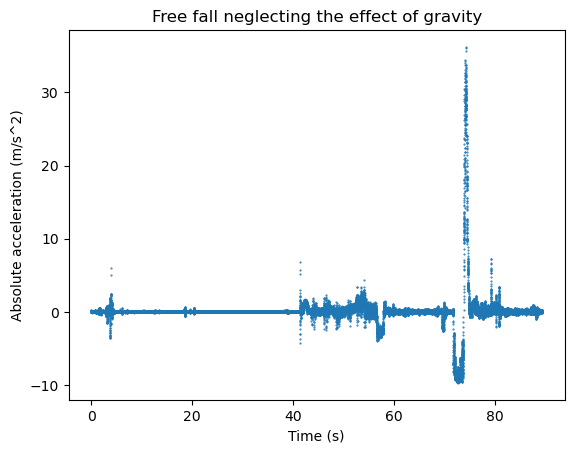

In [192]:
plt.errorbar(data.iloc[:, 0], data.iloc[:, 1], fmt=".", markersize=1)
plt.xlabel(data.columns[0]); plt.ylabel(data.columns[1])
plt.title("Free fall neglecting the effect of gravity")
pass

### We can use the standard error for the Absolute acceleration uncertainity and the time interval as the time uncertainity

In [214]:
# Get the uncertanity values

time_uncertainity = data["Time (s)"][1] - data["Time (s)"][0]
uncertainty = np.std(data["Absolute acceleration (m/s^2)"], ddof=1)

# Populates the data frame with estimated values

data["Acceleration_uncertainity (m/s^2)"] = uncertainty
data["Time_uncertainity (s)"] =  time_uncertainity

data.head()


,Time (s),Absolute acceleration (m/s^2),Acceleration_uncertainity (m/s^2),Time_uncertainity (s),Velocity (m/s)
0,0.018343,0.168956,2.506107,0.002378,0.000000
1,0.020721,0.156003,2.506107,0.002378,0.000000
2,0.023099,0.101700,2.506107,0.002378,0.000386
3,0.025478,0.065408,2.506107,0.002378,0.000693
4,0.027856,0.036018,2.506107,0.002378,0.000892


The uncertainties are given as follows:

$$
\text{Acceleration uncertainty} = 3
$$

$$
\text{Time uncertainty} = 0.002
$$


## Plots the acceleration data point with the calculated uncertainity

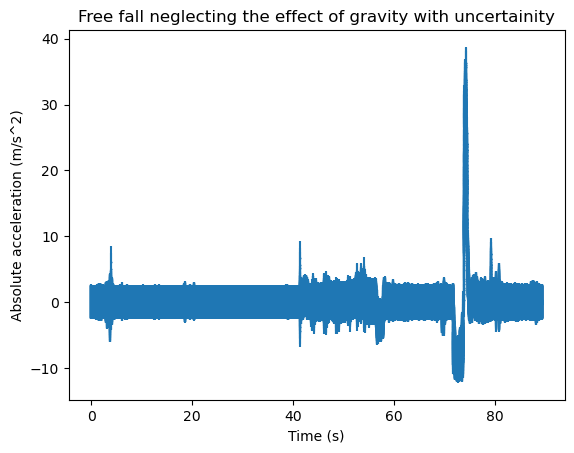

In [370]:
plt.errorbar(data.iloc[:, 0], data.iloc[:, 1], fmt=".", markersize=1, 
             xerr=data["Time_uncertainity (s)"], yerr=data["Acceleration_uncertainity (m/s^2)"])
plt.xlabel(data.columns[0]); plt.ylabel(data.columns[1])
plt.title("Free fall neglecting the effect of gravity with uncertainity")
pass

# Dominant source of uncertainity:

#### The dominant source of uncertainty for this measurement:is the unintended interactions with our phone before and after the fall. As seen in our plot, there is increased fluctuation in our data points at the start of the ride when the shuttle begins moving, and at the end of the ride, which is most likely when the phone sensors experience unintended vibrations or touches.

### Now, we calculate the velocity during ascent and descent using the numpy.trapz() integral

In [374]:
velocities = []     # Make an empty list where we will store our newly calculate velocities

# This goes through every row of data one by one. 
# The for loop goes from the first element of the data table to the last, with the size 
# given by the length of the data["time"] row (data["time"].size). That is, i=0, 1, 2, ..., (length of the table)
for i in range(data["Time (s)"].size): 
    
    # Here I am selecting multiple rows and ALL columns, up to the i-th row
    data_up_to_this_row = data.head(i)
    
    # Now, get the x- and y-values for the integral from our slice of data
    ts  = data_up_to_this_row["Time (s)"]
    acc = data_up_to_this_row["Absolute acceleration (m/s^2)"] 
    
    # Calculate the integral
    v   = np.trapz(acc, ts)
    
    # Finally, add the new velocity to the velocity list
    velocities.append(v)    
    
# Make a new column in the data frame to store the velocities
data["Velocity (m/s)"] = velocities
data.head()

,Time (s),Absolute acceleration (m/s^2),Acceleration_uncertainity (m/s^2),Time_uncertainity (s),Velocity (m/s),position (m)
0,0.018343,0.168956,2.506107,0.002378,0.000000,0.000000e+00
1,0.020721,0.156003,2.506107,0.002378,0.000000,0.000000e+00
2,0.023099,0.101700,2.506107,0.002378,0.000386,0.000000e+00
3,0.025478,0.065408,2.506107,0.002378,0.000693,4.595700e-07
4,0.027856,0.036018,2.506107,0.002378,0.000892,1.743136e-06


### Plotting our velocity time graph to get a visual of how our graph looks

### Since the uncertainity of the acceleration is 2.5 we can neglect all the other uncertainities because it dominates all the others

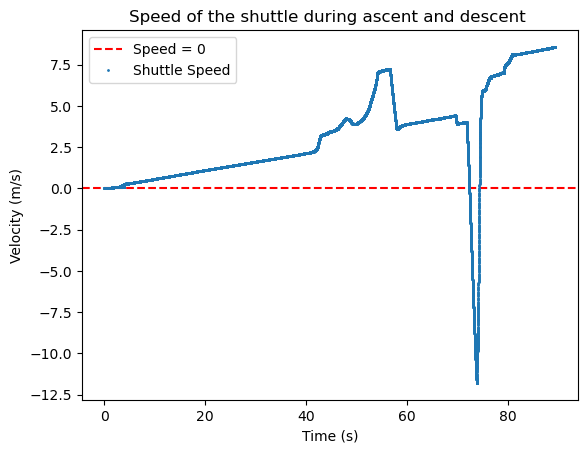

In [377]:
plt.errorbar(data.iloc[:, 0], data["Velocity (m/s)"], fmt=".", markersize=2, label="Shuttle Speed")
plt.xlabel(data.columns[0]); plt.ylabel("Velocity (m/s)")
plt.title("Speed of the shuttle during ascent and descent ")
plt.axhline(y=0, linestyle="--", c="r", label="Speed = 0")
plt.legend()

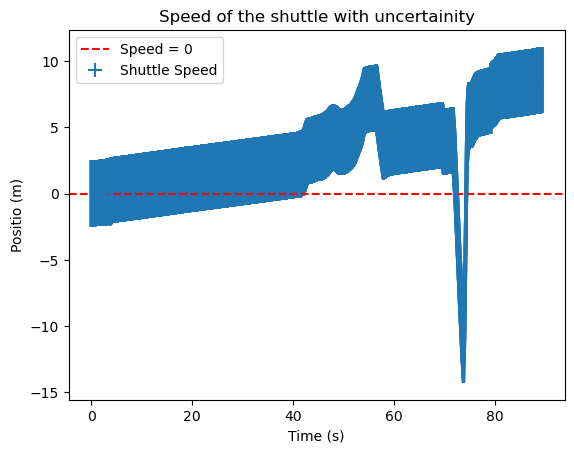

In [378]:
plt.errorbar(data.iloc[:, 0], data["Velocity (m/s)"], fmt=".",
             xerr=data["Time_uncertainity (s)"], yerr=data["Acceleration_uncertainity (m/s^2)"],markersize=1, label="Shuttle Speed")
plt.xlabel(data.columns[0]); plt.ylabel("Positio (m)")
plt.title("Speed of the shuttle with uncertainity")
plt.axhline(y=0, linestyle="--", c="r", label="Speed = 0")
plt.legend()
pass

# Getting the maximum speed

In [381]:
max_speed = max(np.abs(data["Velocity (m/s)"]))

# Getting the 
print(f"Maximum speed measured = {max_speed:.1f}")

Maximum speed measured = 11.8


## Answer for the Maximum Speed Throughout the Journey >>>

#### Although it is difficult to determine the exact maximum speed, based on the data we collected, we can estimate it to be 

$$
\text{Maximum speed} = 12 \pm 3 \, \text{m/s}
$$

# Now, we calculate the position of our shuttle during ascent and descent using the numpy.trapz() integral

In [384]:
position = []     # Make an empty list where we will store our newly calculate velocities

# This goes through every row of data one by one. 
# The for loop goes from the first element of the data table to the last, with the size 
# given by the length of the data["time"] row (data["time"].size). That is, i=0, 1, 2, ..., (length of the table)
for i in range(data["Time (s)"].size): 
    
    # Here I am selecting multiple rows and ALL columns, up to the i-th row
    data_up_to_this_row = data.head(i)
    
    # Now, get the x- and y-values for the integral from our slice of data
    ts  = data_up_to_this_row["Time (s)"]
    acc = data_up_to_this_row["Velocity (m/s)"] 
    
    # Calculate the integral
    v   = np.trapz(acc, ts)
    
    # Finally, add the new velocity to the velocity list
    position.append(v)    
    
# Make a new column in the data frame to store the velocities
data["position (m)"] = position



In [385]:
data.head()

,Time (s),Absolute acceleration (m/s^2),Acceleration_uncertainity (m/s^2),Time_uncertainity (s),Velocity (m/s),position (m)
0,0.018343,0.168956,2.506107,0.002378,0.000000,0.000000e+00
1,0.020721,0.156003,2.506107,0.002378,0.000000,0.000000e+00
2,0.023099,0.101700,2.506107,0.002378,0.000386,0.000000e+00
3,0.025478,0.065408,2.506107,0.002378,0.000693,4.595700e-07
4,0.027856,0.036018,2.506107,0.002378,0.000892,1.743136e-06


### Plotting our position vs time graph so that we get a visual of how our shuttle is changing position in real time

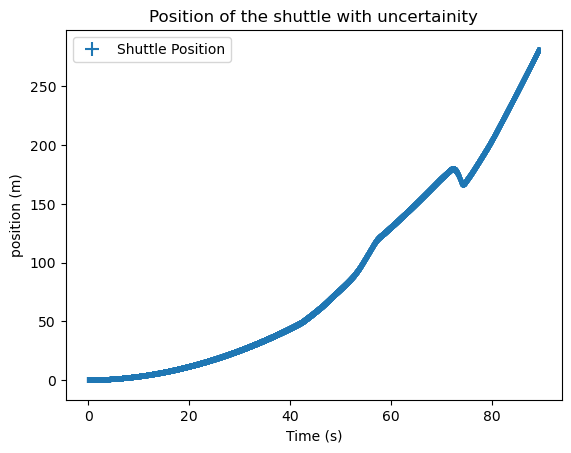

In [387]:
plt.errorbar(data.iloc[:, 0], data.iloc[:, -1], fmt=".",
             xerr=data["Time_uncertainity (s)"], yerr=data["Acceleration_uncertainity (m/s^2)"],
             markersize=1, label="Shuttle Position")
plt.xlabel(data.columns[0]); plt.ylabel(data.columns[-1])
plt.title("Position of the shuttle with uncertainity")
plt.legend()
pass

## Since the uncertainity of the acceleration is 2.5 we can neglect all the other uncertainities because it dominates all the others

# Getting the maximum height

### The maximum height is the distance the shuttle travels before it starts going down. To calculate this what we are going to do is get the time interval of when our velocity becomes negative and plot the resolution

In [455]:
decent = data[data["Velocity (m/s)"] < 0]
len(decent)

846

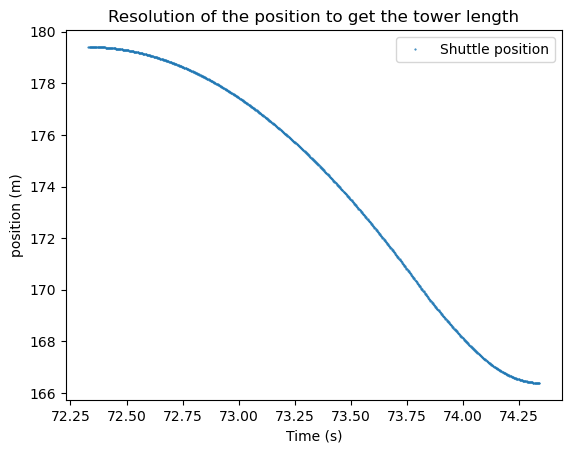

In [457]:
plt.errorbar(decent.iloc[:, 0], decent.iloc[:, -1], fmt=".",
             markersize=1, label="Shuttle position")
plt.xlabel(data.columns[0]); plt.ylabel(data.columns[-1])
plt.title("Resolution of the position to get the tower length")
plt.legend()
pass

In [452]:
## Getting the max height

max_height = np.max(decent["position (m)"])
print(f"Height of the tower = {max_height}")

Height of the tower = 179.41287396936906


The height of the tower is:

$$
\text{Height of the tower} = 180 \pm 3 \, \text{meters}
$$


# Connection to Physics

### From the velocity graph, we can see that the velocity is positive and steadily accelerating when going up the tower. After the fall, the velocity quickly decreases due to gravitational free fall.
### We can also observe that the position steadily increases until the free fall. However, one thing this data failed to capture is that the position should have returned to zero during the free fall. Since this was not captured by our data points, our accelerometer did not record this.


## Calculating the height with out the data 

The height of the tower is calculated using trigonometry:

$$
H_{\text{tower}} = h_{\text{eye}} + H \cdot \tan(\theta)
$$




where:
$$
\begin{align*}
& h_{\text{eye}} = 1.61 \\
& H = 29.55  \\
& \theta = 49^\circ \quad \text{(angle to the top of the tower)}
\end{align*}
$$

Substituting the values:

$$
H_{\text{tower}} = 1.61 + 29.55 \cdot \tan(49^\circ) \approx 35.60 \, \text{m}
$$

Propagation of uncertainty:

$$
\Delta H_{\text{tower}} = \sqrt{ \left( \Delta h_{\text{eye}} \right)^2 + \left( \tan(\theta) \cdot \Delta H \right)^2 + \left( H \cdot \sec^2(\theta) \cdot \Delta \theta \right)^2 }
$$

Substituting values:

$$
\Delta H_{\text{tower}} = \sqrt{ (0.01)^2 + \left( \tan(49^\circ) \cdot 0.13 \right)^2 }
$$

Calculating tower height and its uncertainty:

$$
H_{\text{tower}} = 1.61 + 29.55 \cdot \tan(49^\circ) \approx 35.60 \pm 1.80 \, \text{m}
$$













# Comparison between Our Estimated Height and the Actual Height

### For some reason, our estimate for the position is significantly off from reality. This discrepancy could be due to an error in our calculations or the resolution of our accelerometer not being sufficient. However, one thing our measurements captured well is the change in speed and position. As we can see from the plot, it is easy to notice that the velocity dips into a high negative value during the free fall.


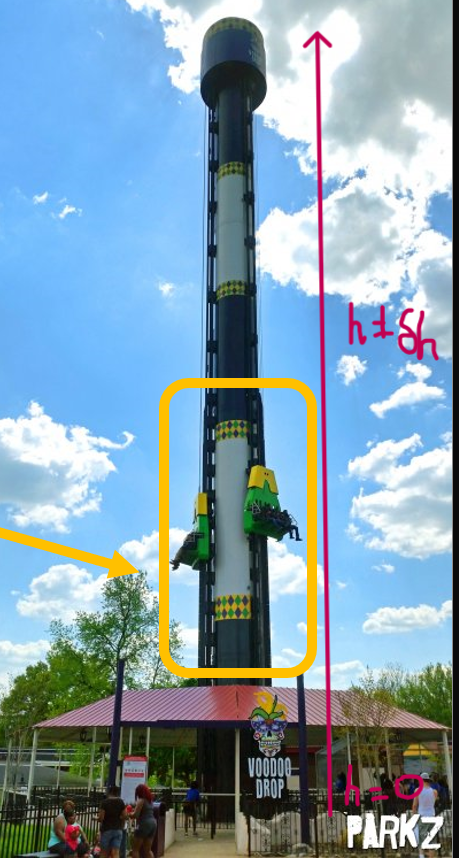